# PerovStats demo notebook
This notebook is for demonstrating the processes involved in PerovStats, from deciding on configuration options and running the modules.

In [ ]:
%load_ext autoreload
%autoreload 2

import os
import sys
import time

from loguru import logger
from pathlib import Path
import yaml
from topostats.io import LoadScans
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

sys.path.append(os.path.abspath(os.path.join('..')))
from src.perovstats.core.classes import PerovStats, ImageData
from src.perovstats.core.io import save_to_csv, save_config
from src.perovstats.cli import setup_logger
from src.perovstats.fourier import split_frequencies
from src.perovstats.segmentation import segment_image_cellpose, normalise_array
from src.perovstats.pruning import prune_mask
from src.perovstats.smears import find_smear_areas
from src.perovstats.grains import find_grains

These options can be changed to suit your needs. the `output_dir` folder will contain a selection of images from various stages in the process as well as the `.csv` files generated.

In [2]:
img_files = [Path("../images/4_c60_perovonsil_ref_10um.PFQNM.spm")]
# img_files = [Path("../images/TR_5um_ST4_14_26_per_Si_tapp4.0_00010.spm")]
output_dir = Path("./output")
config_path = Path("../src/perovstats/default_config.yaml")

[Tue, 31 Mar 2026 10:58:34] [INFO    ] [topostats] Extracting image from ..\images\4_c60_perovonsil_ref_10um.PFQNM.spm
10:58:34 | INFO    | spm.py          | Loading image from : ..\images\4_c60_perovonsil_ref_10um.PFQNM.spm
10:58:34 | INFO    | spm.py          | [4_c60_perovonsil_ref_10um.PFQNM] : Loaded image from : ..\images\4_c60_perovonsil_ref_10um.PFQNM.spm
10:58:34 | INFO    | spm.py          | [4_c60_perovonsil_ref_10um.PFQNM] : Extracted channel Height
10:58:34 | INFO    | spm.py          | [4_c60_perovonsil_ref_10um.PFQNM] : Pixel to nm scaling : 19.53125
10:58:34 | INFO    | 1114820156.py   | ----------------------------------------------------------
10:58:34 | INFO    | 1114820156.py   | Loaded 1 images


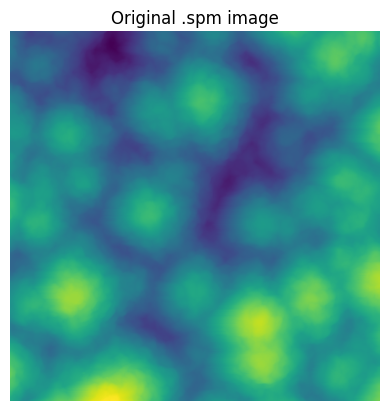

In [3]:
setup_logger()

with config_path.open() as f:
    config = yaml.safe_load(f)

time_start = time.perf_counter()

# Load scans
load_config = config["loading"]
loadscans = LoadScans(img_files, config)
try:
    loadscans.get_data()
except ValueError as e:
    logger.warning(e)
    logger.warning(f"Channel {load_config['channel']} not found in file. Please ensure the config option is correct and all files contain the required channel.")
image_dicts = loadscans.img_dict

# Create the dataclasses for the whole process and for each image found
perovstats_object = PerovStats(config=config, images=[])
for filename, topostats_object in image_dicts.items():
    image_data = ImageData(
        success=True,
        filename=filename,
        pixel_to_nm_scaling=topostats_object.pixel_to_nm_scaling,
        image_original=topostats_object.image_original,
        image_flattened=None)
    perovstats_object.images.append(image_data)

logger.info("----------------------------------------------------------")
logger.info(f"Loaded {len(perovstats_object.images)} images")

idx = 0
image_object = perovstats_object.images[0]

plt.imshow(image_object.image_original)
plt.title("Original .spm image")
plt.axis("off")
plt.show()

In [4]:
logger.info("----------------------------------------------------------")
logger.info(f"Processing {image_object.filename} ({idx+1}/{len(perovstats_object.images)})")
logger.info("----------------------------------------------------------")
logger.debug(f"[{image_object.filename}] : Image dimensions: {image_object.image_original.shape}")
logger.debug(f"[{image_object.filename}] : pixel_to_nm_scaling: {image_object.pixel_to_nm_scaling}")

10:58:34 | INFO    | 1697177067.py   | ----------------------------------------------------------
10:58:34 | INFO    | 1697177067.py   | Processing 4_c60_perovonsil_ref_10um.PFQNM.spm (1/1)
10:58:34 | INFO    | 1697177067.py   | ----------------------------------------------------------
10:58:34 | DEBUG   | 1697177067.py   | [4_c60_perovonsil_ref_10um.PFQNM.spm] : Image dimensions: (512, 512)
10:58:34 | DEBUG   | 1697177067.py   | [4_c60_perovonsil_ref_10um.PFQNM.spm] : pixel_to_nm_scaling: 19.53125


Fourier Config: {'run': True, 'edge_width': 0.01, 'cutoff_bounds': [0, 0.3], 'min_rms': 10}
10:58:34 | INFO    | fourier.py      | [4_c60_perovonsil_ref_10um.PFQNM.spm] : *** Frequency splitting ***
10:58:34 | INFO    | fourier.py      | [4_c60_perovonsil_ref_10um.PFQNM.spm] : Frequency cutoff: 0.1248 (312.989nm)
10:58:34 | INFO    | fourier.py      | [4_c60_perovonsil_ref_10um.PFQNM.spm] : Splitting image frequencies
--- HIGH PASS DATA AUDIT ---
Data Type: float64
Mean:      0.009946122495694
Std Dev:   11.385373069650065
Max Value: 34.771871581213503


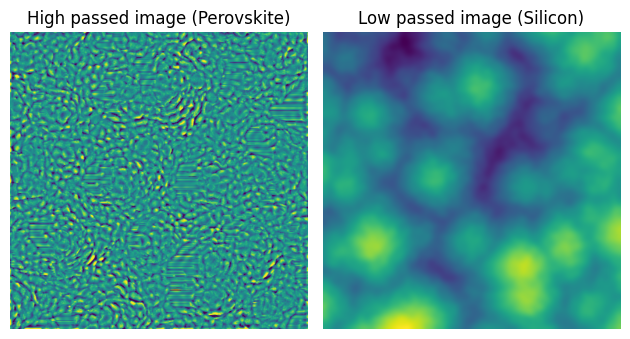

In [ ]:
# Apply fourier transform to split the image into a low-passed and high-passed image
split_frequencies(perovstats_object.config, image_object)

# Show the split images
fig, ax = plt.subplots(1, 2)

ax[0].imshow(image_object.high_pass)
ax[0].set_title("High passed image (Perovskite)")
ax[0].axis("off")

ax[1].imshow(image_object.low_pass)
ax[1].set_title("Low passed image (Silicon)")
ax[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Generate grain mask of the high-passed image
segment_image_cellpose(perovstats_object.config, image_object)

10:58:35 | INFO    | segmentation.py | [4_c60_perovonsil_ref_10um.PFQNM.spm] : *** Mask creation ***
10:58:35 | INFO    | segmentation.py | [4_c60_perovonsil_ref_10um.PFQNM.spm] : Creating grain mask


10:58:41 | INFO    | pruning.py      | [4_c60_perovonsil_ref_10um.PFQNM.spm] : *** Pruning ***


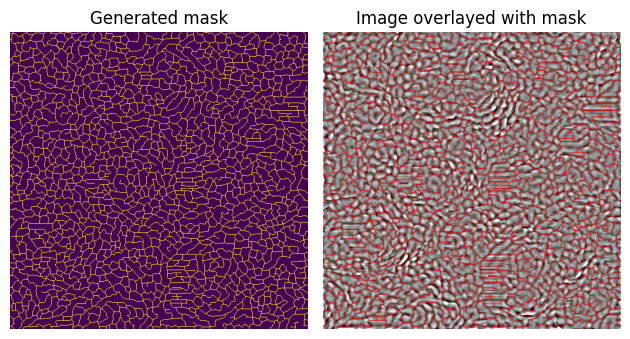

In [7]:
# Remove small offshoots in the mask and connect sections with small breaks
prune_mask(perovstats_object.config, image_object)


# Display the generated mask on its own and overlayed onto the high pass image
fig, ax = plt.subplots(1, 2)

ax[0].imshow(image_object.mask)
ax[0].set_title("Generated mask")
ax[0].axis("off")

mask_overlay = np.stack((image_object.high_pass,)*3, axis=-1)
mask_overlay = normalise_array(mask_overlay)
mask_overlay[image_object.mask > 0] = [1, 0, 0]
ax[1].imshow(mask_overlay)
ax[1].set_title("Image overlayed with mask")
ax[1].axis("off")

plt.tight_layout()
plt.show()

In [8]:
# Find smear areas to be ignored/ removed
find_smear_areas(perovstats_object.config, image_object)

10:58:42 | INFO    | smears.py       | [4_c60_perovonsil_ref_10um.PFQNM.spm] : *** Finding smear areas ***
10:58:43 | INFO    | smears.py       | [4_c60_perovonsil_ref_10um.PFQNM.spm] : Smear areas found: 25 (11.09% of mask)


10:58:43 | INFO    | grains.py       | [4_c60_perovonsil_ref_10um.PFQNM.spm] : *** Grain finding ***
10:58:43 | INFO    | grains.py       | [4_c60_perovonsil_ref_10um.PFQNM.spm] : Obtained 774 grains


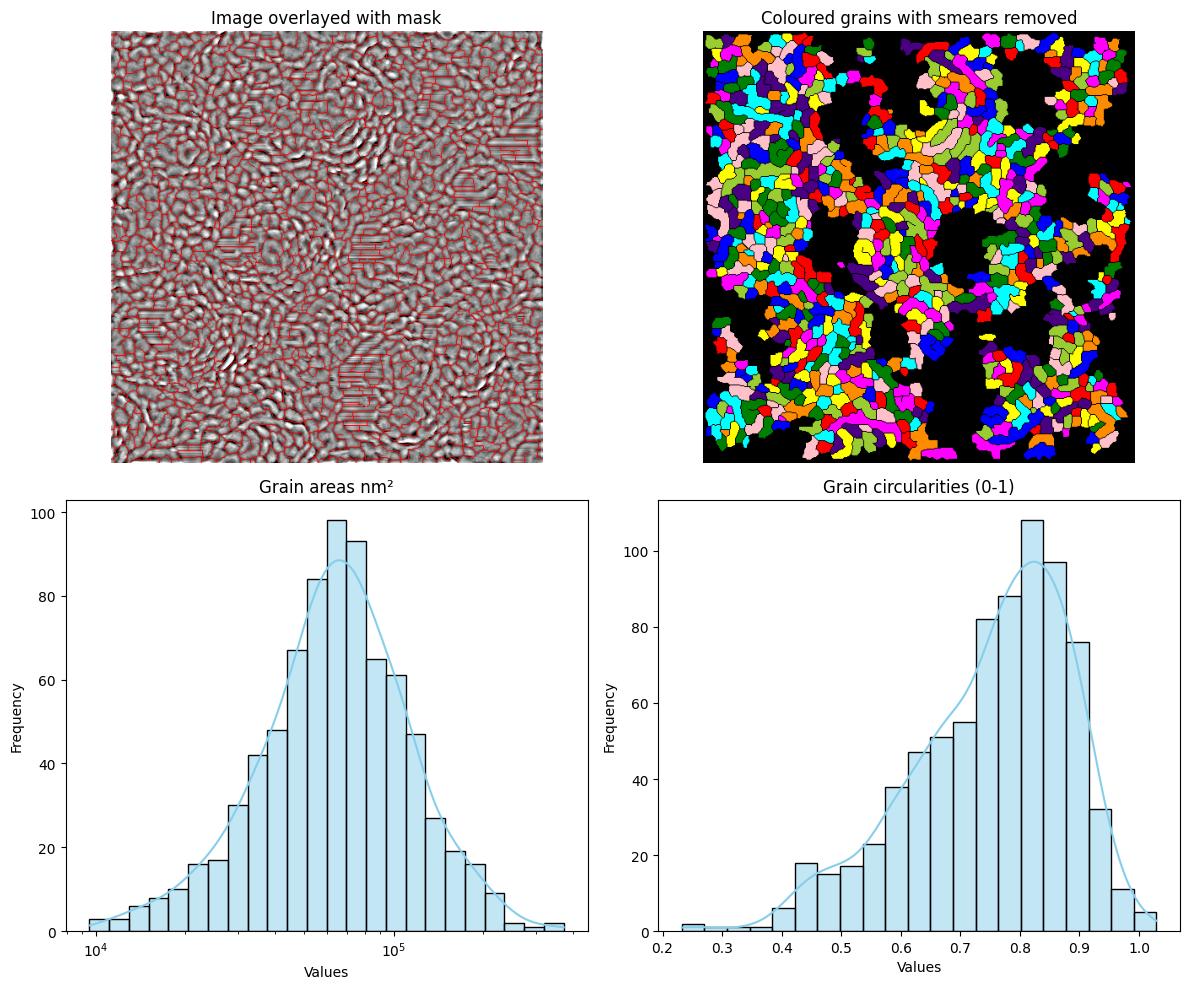

In [9]:
import seaborn as sns

# Identify individual grains from mask and generate statistics on them
find_grains(perovstats_object.config, image_object)


# Display data and statistics on the processed image and grains
fig, ax = plt.subplots(2, 2, figsize=(12, 10))

ax[0,0].imshow(mask_overlay)
ax[0,0].set_title("Image overlayed with mask")
ax[0,0].axis("off")

ax[0,1].imshow(image_object.mask_rgb)
ax[0,1].set_title("Coloured grains with smears removed")
ax[0,1].axis("off")

sns.histplot(image_object.mask_areas, bins='auto', kde=True, log_scale=True, color='skyblue', edgecolor='black', ax=ax[1,0])
ax[1,0].set_xlabel('Values')
ax[1,0].set_ylabel('Frequency')
ax[1,0].set_title('Grain areas nm²')

sns.histplot(image_object.circularity_data, bins='auto', kde=True, color='skyblue', edgecolor='black', ax=ax[1,1])
ax[1,1].set_xlabel('Values')
ax[1,1].set_ylabel('Frequency')
ax[1,1].set_title('Grain circularities (0-1)')

plt.tight_layout()
plt.show()

Data, including the config options used in the run, are now exported to the output directory chosen at the top of this notebook.

In [10]:
logger.info(f"[{image_object.filename}] : *** Exporting data ***")
# Save image and grain data to their own .csv file
image_df = pd.DataFrame([image_object.to_dict()])
grains_list = []
for grain in image_object.grains.values():
    grains_list.append(grain.to_dict())
grain_df = pd.DataFrame(grains_list)

output_filename = f"{output_dir}/{image_object.filename}/image_statistics.csv"
save_to_csv(image_df, output_filename)
output_filename = f"{output_dir}/{image_object.filename}/grain_statistics.csv"
save_to_csv(grain_df, output_filename)
# Save the config settings in a .yaml
output_filename = Path(output_dir) / Path(image_object.filename) / "config.yaml"
save_config(perovstats_object.config, output_filename)

logger.info(
    f"[{image_object.filename}] : Exported data and config to {Path(output_dir) / Path(image_object.filename)}",
)

10:58:44 | INFO    | 2787836878.py   | [4_c60_perovonsil_ref_10um.PFQNM.spm] : *** Exporting data ***
10:58:44 | INFO    | 2787836878.py   | [4_c60_perovonsil_ref_10um.PFQNM.spm] : Exported data and config to output\4_c60_perovonsil_ref_10um.PFQNM.spm
